# scATAC-seq clustering analysis

Here we will use 10X PBMCs scRNA-seq dataset from scanpy as an example to illustrate how Garfield performs scRNA-seq clustering analysis

In [1]:
# load packages
import os
import Garfield as gf
import scanpy as sc
gf.__version__

'0.1.2'

In [2]:
adata = sc.read_h5ad('../Garfield_test/example_data/atac_buenrostro2018.h5ad')
adata

AnnData object with n_obs × n_vars = 2034 × 237450
    obs: 'celltype'
    var: 'chr', 'start', 'end'

In [3]:
# set workdir
workdir = 'result_garfield_atac_10xpbmc5k'
gf.settings.set_workdir(workdir)

Saving results in: result_garfield_atac_10xpbmc5k


In [4]:
gf.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

In [5]:
# make plots prettier
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

In [6]:
def set_gf_params(config=None):
    """Set Garfield parameters

    Parameters
    ----------
    config : `dict`, optional
        Garfield training configuration parameters.

    Returns
    -------
    """
    default_config = {
        # Input options
        'data_dir': 'data',
        'project_name': 'test',
        'adata_list': ['test.h5ad'],
        'profile': 'RNA',
        'data_type': None,
        'sample_col': None,

        ## whether to use metacell mode
        'metacell': False,
        'metacell_size': 1,
        'single_n_top_genes': 2000,
        'n_pcs': 20,

        # Preprocessing options
        'filter_cells_rna': True,
        'min_features': 100,
        'min_cells': 3,
        'keep_mt': False,
        'normalize': True,
        'target_sum': 1e4,
        'used_hvg': True,
        'used_scale': True,
        'rna_n_top_features': 2000,
        'atac_n_top_features': 10000,
        'n_neighbors': 15,
        'svd_solver': 'arpack',
        'method': 'umap',
        'metric': 'euclidean',
        'resolution_tol': 0.1,
        'leiden_runs': 1,
        'leiden_seed': None,
        'verbose': True,

        # Model options
        'gnn_layer': 2,
        'conv_type': 'GAT',
        'hidden_dims': [128, 128],
        'bottle_neck_neurons': 20,
        'svd_q': 5,
        'cluster_num': 20,
        'num_heads': 3,
        'concat': True,
        'used_edge_weight': True,
        'used_recon_exp': True,
        'used_DSBN': False,
        'used_mmd': False,
        'test_split': 0.1,
        'val_split': 0.1,
        'batch_size': 128,
        'num_neighbors': [3, 3],
        'epochs': 50,
        'dropout': 0.2,
        'mmd_temperature': 0.2,
        'instance_temperature': 1.0,
        'cluster_temperature': 0.5,
        'l2_reg': 1e-03,
        'patience': 5,
        'monitor_only_val_losses': True,
        'gradient_clipping': 5,
        'learning_rate': 0.001,
        'weight_decay': 1e-05,

        # Other options
        'outdir': None,
        'load': False
    }

    ## user_config
    if config is None:
        config = {}  # 如果 `config` 为空则设为空字典

    user_config = config
    config = {**default_config, **user_config}

    assert config['adata_list'] is not None, 'The input `adata_list` must not be empty.'
    assert config['profile'] in ['RNA', 'ATAC', 'multi-modal'], \
        'The `profile` should be set as one of the `RNA`, `ATAC`, `multi-modal`.'
    if config['profile'] == 'multi-modal':
        assert config['data_type'] in ['Paired', 'UnPaired'], \
            'The `data_type` should be set as one of the `Paired`, `UnPaired`.'
    assert config['conv_type'] in ['GAT', 'GCN'], \
        'The current model only supports `GAT` or `GCN` layers.'

    return config

In [7]:
### modify parameter
user_config = dict(
    ## Input options
    data_dir=workdir,  # STR     Location of the dataset to be used.         Default is `data`.
    project_name='atac_buenrostro2018',  # STR     Name of the dataset to be used.             Default is `name`.
    adata_list=['../Garfield_test/example_data/atac_buenrostro2018.h5ad'],  # STR     adata object of single-cell dataset.         Default is `adata`.
    profile='ATAC',
    data_type=None,  # Paired
    genome='hg38',
    sample_col=None,  # STR     Column name of sample in adata.obs.       Default is `batch`.

    ## Preprocessing options
    atac_n_top_features=10000,  # INT     Number of top genes to be selected.       Default is 2000.
    metric='euclidean',  # STR     Metric for clustering.                   Default is `correlation`. euclidean

    ## Model options
    gnn_layer=2,
    hidden_dims=[128, 128],
    svd_q=5,  # default=5, type=int, help='rank'
    cluster_num=20,
    used_edge_weight=True,
    used_recon_exp=True,
    used_DSBN=False,
    used_mmd=False,
    batch_size=128,  # INT   batch size of model training
    num_neighbors=[5, 5],
    epochs=50,  # INT       Number of epochs.                        Default is 100.
    mmd_temperature=0.2,  ## mmd regu
    instance_temperature=1.0,
    cluster_temperature=0.5,
    learning_rate=0.0001
)
dict_config = set_gf_params(user_config)

In [8]:
## start training
from Garfield.model import GarfieldTrainer
trainer = GarfieldTrainer(dict_config)
trainer.fit()


Preparing dataset...

Data files exist, loading...
Finished loading.

Model training.

 |█████████-----------| 48.0%  - val_total_loss: 2885.8527832031 - val_vgae_loss: 4.0312581062 - val_instance_loss: 7.5429487228 - val_cluster_loss: 3.4282047749 - val_recon_loss: 1674.4382324219 - val_mod_recon_loss: 2027.0261230469 - val_regu_loss: 6.6052269936 - val_mmd_loss: 0.00000000000

EarlyStopping: run 24 epoch
Model is saved under result_garfield_atac_10xpbmc5k/checkpoint/model.pt.


In [9]:
import scanpy as sc
adata_final = trainer.get_latent_representation()
adata_final

eval mode
Perform get_latent for cells via mini-batch mode


AnnData object with n_obs × n_vars = 2031 × 10016
    obs: 'celltype', 'nb_features'
    var: 'chr', 'start', 'end', 'n_cells', 'prop_shared_cells', 'variability_score'
    uns: 'log1p', 'pca', 'neighbors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_gf'
    varm: 'PCs'
    layers: 'counts', 'binary', 'normalised'
    obsp: 'distances', 'connectivities'

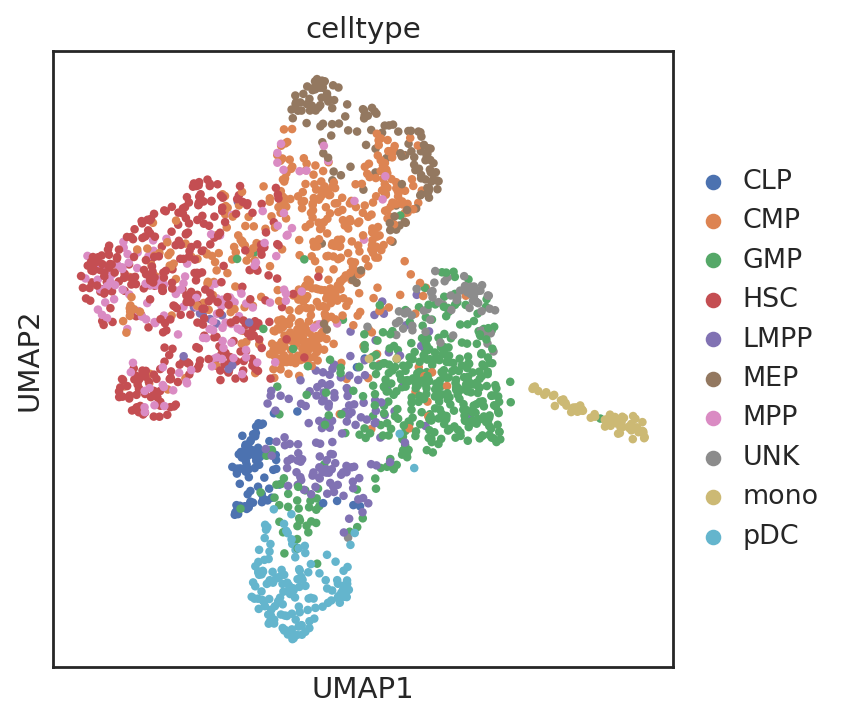

In [10]:
sc.tl.umap(adata_final)
# adata_final.obs['celltype'] = adata_final.obs['celltype'].astype('category')
sc.pl.umap(adata_final, color=['celltype'], wspace=0.15, edges=False)

In [11]:
sc.tl.leiden(adata_final, resolution=1.0)

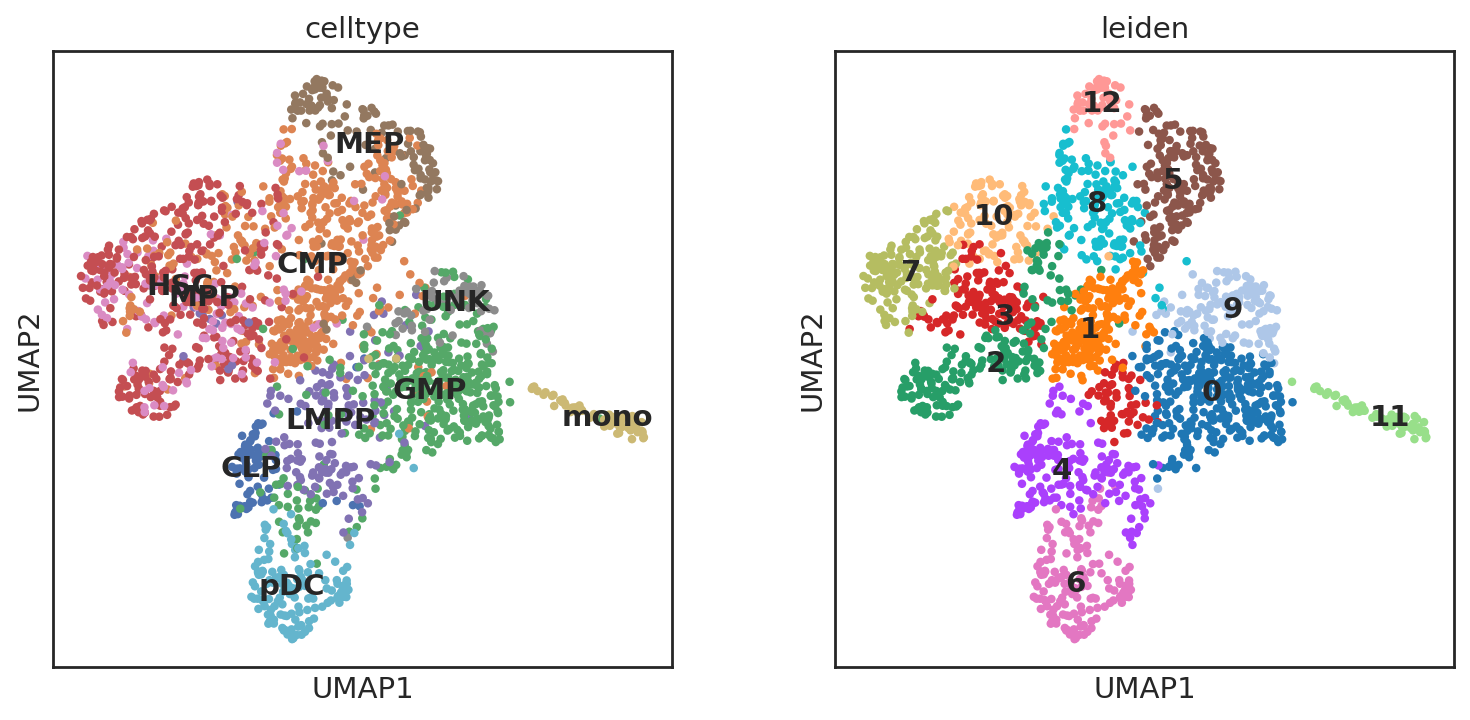

In [12]:
# adata_final.obs['celltype'] = adata_final.obs['louvain']
sc.pl.umap(adata_final, color=['celltype', 'leiden'], wspace=0.15, legend_loc='on data', edges=False, save='_atac_example.pdf')

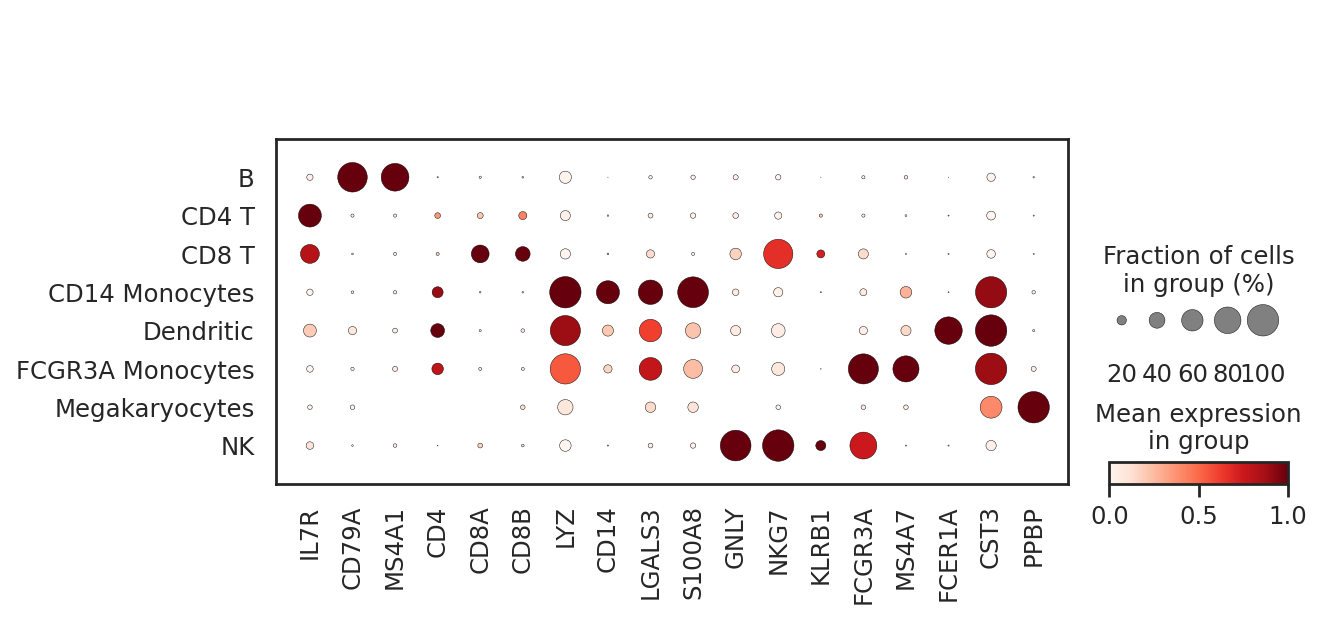

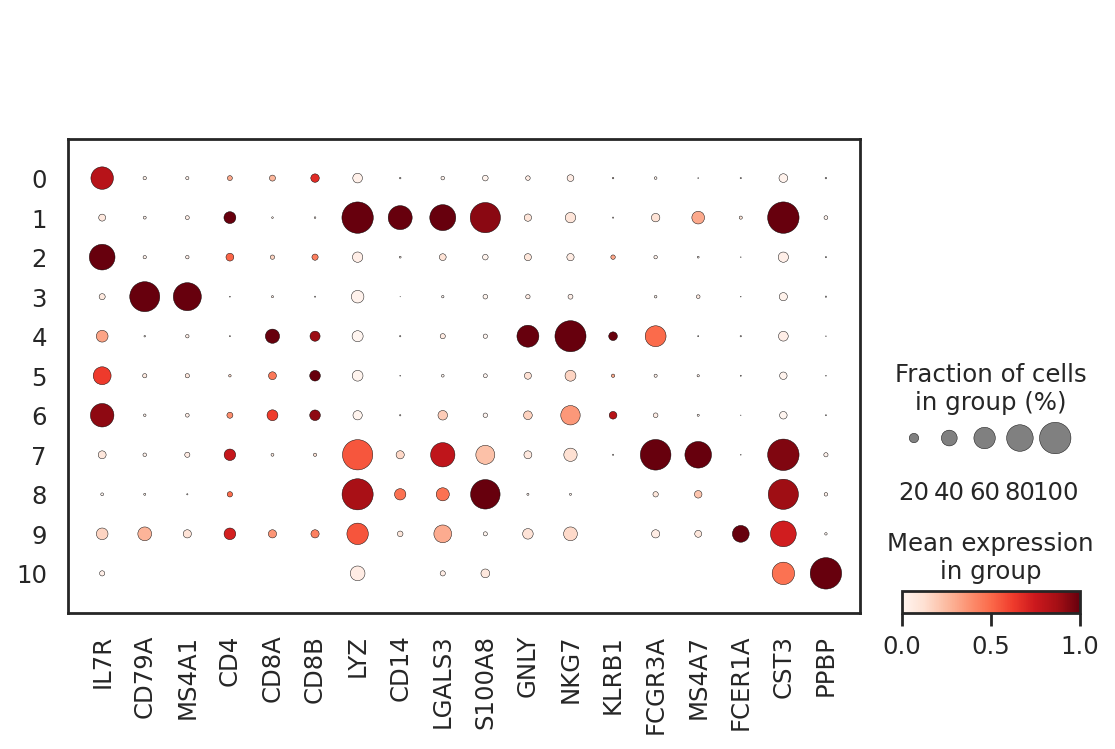

In [24]:
marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD4", "CD8A", "CD8B", "LYZ", "CD14"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]
sc.pl.dotplot(adata_final, marker_genes, groupby="celltype",standard_scale='var')
sc.pl.dotplot(adata_final, marker_genes, groupby="leiden", standard_scale='var');